# Step 1: Data preparation


In [1]:
import os
import copy
import random
import collections
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Scikit-learn Preprocessing, Splitting, and Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, matthews_corrcoef, precision_recall_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

# Imbalanced Learning Frameworks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Machine Learning & Deep Learning Frameworks
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Explainable AI (XAI) Libraries
import shap
import lime
import lime.lime_tabular

import preprocess

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure fully deterministic behavior in PyTorch backends
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
filepath = "data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
df = preprocess.load_and_clean_dataset(filepath)

#change to a binary label
df['Label'] = df['Label'].astype(str).str.strip().str.upper()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = df.drop(columns=['Label'])
y = df['Label'].values

print(f"[*] Cleaned Feature matrix shape: {X.shape}")
print(f"[*] Target distribution: Benign (0) = {np.sum(y == 0)}, Attack (1) = {np.sum(y == 1)}")


[*] Loading raw dataset from: data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
[*] Dataset Ingestion & Cleaning Audit:
    -> Raw Rows Ingested:          458,968
    -> Empty CSV Padding Purged:   288,602
    -> Valid Network Flows:        170,366
    -> Invalid Flows Dropped (Inf/NaN): 135
    -> Final Usable Flows:         170,231
[*] Cleaned Feature matrix shape: (170231, 78)
[*] Target distribution: Benign (0) = 168051, Attack (1) = 2180


In [4]:
# Step A: Split off 30% of the data into a temporary block, stratifying to preserve class ratios
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step B: Split the temporary block evenly to yield a 15% Validation set and a 15% Test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("==================== DATA SPLIT SUMMARY ====================")
print(f"Training Set (70%):   X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation Set (15%): X = {X_val.shape}, y = {y_val.shape}")
print(f"Test Set (15%):       X = {X_test.shape}, y = {y_test.shape}")

==================== DATA SPLIT SUMMARY ====================
Training Set (70%):   X = (119161, 78), y = (119161,)
Validation Set (15%): X = (25535, 78), y = (25535,)
Test Set (15%):       X = (25535, 78), y = (25535,)


In [5]:
# 1. Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 2. Correlated Feature Groups (Supervisor point 15 & 16)
corr_matrix = X_train_scaled.corr(method="spearman")
# Get upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find columns with correlation > 0.90
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.90)]

print(f"[*] Features identified for potential removal (>0.90 correlation): {len(to_drop)}")

[*] Features identified for potential removal (>0.90 correlation): 39


In [6]:
# Initialize SMOTE-Tomek with a fixed seed for strict reproducibility
smote_tomek = SMOTETomek(random_state=42)

# Resample ONLY the training set
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_scaled,
    y_train
)

print("================= RESAMPLING SUMMARY =================")
print(f"Original Training Class Ratios: 0 = {np.sum(y_train == 0)}, 1 = {np.sum(y_train == 1)}")
print(f"Resampled Training Data Shape:  X = {X_train_resampled.shape}, y = {y_train_resampled.shape}")
print(f"Resampled Training Class Ratios: 0 = {np.sum(y_train_resampled == 0)}, 1 = {np.sum(y_train_resampled == 1)}")

================= RESAMPLING SUMMARY =================
Original Training Class Ratios: 0 = 117635, 1 = 1526
Resampled Training Data Shape:  X = (235254, 78), y = (235254,)
Resampled Training Class Ratios: 0 = 117627, 1 = 117627


# Step 2: Model development

In [7]:
print("[*] Initializing XGBoost Classifier...")

# Initialize XGBoost with strict reproducibility parameters
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.1,
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=15
)

# Fit model with early stopping monitored against the validation split
xgb_model.fit(
    X_train_resampled, 
    y_train_resampled,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

print(f"[*] XGBoost training complete.")
print(f"    -> Best Iteration: {xgb_model.best_iteration}")

[*] Initializing XGBoost Classifier...


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\thesis_env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [16:35:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[*] XGBoost training complete.
    -> Best Iteration: 398


In [8]:
class BaselineDNN(nn.Module):
    def __init__(self, input_dim):
        super(BaselineDNN, self).__init__()
        
        # Layer 1: Input to Hidden 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.30)
        
        # Layer 2: Hidden 1 to Hidden 2
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.30)
        
        # Layer 3: Hidden 2 to Output Layer
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.sigmoid(self.fc3(x))
        return x

# Set calculation device backend
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_features_count = X_train_resampled.shape[1]

# Instantiate model architecture as BaselineDNN
model_dnn = BaselineDNN(input_dim=input_features_count).to(device)
print(f"[*] Baseline DNN mapped successfully onto target hardware device: {device.type.upper()}")

[*] Baseline DNN mapped successfully onto target hardware device: CPU


In [9]:
# Convert DataFrames/Arrays to PyTorch multi-dimensional tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_resampled.values),
    torch.FloatTensor(y_train_resampled).unsqueeze(1)
)
val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)
val_y_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)

# Configure data loader iterations
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Set optimizer equations and standard binary loss scoring
criterion = nn.BCELoss()
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001)

# Early Stopping parameters
patience = 10
best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0
max_epochs = 150

print("[*] Initiating DNN optimization loop...")
for epoch in range(1, max_epochs + 1):
    model_dnn.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_dnn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        
    # Validation Evaluation Phase (Zero Leakage Check)
    model_dnn.eval()
    with torch.no_grad():
        val_outputs = model_dnn(val_x_tensor)
        val_loss = criterion(val_outputs, val_y_tensor).item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    
    # Early stopping criteria tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model_dnn.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"[*] Early stopping triggered at Epoch {epoch}. Overfitting threshold neutralized.")
        break

# Roll back parameter matrix states to the optimal captured validation validation loss weights
if best_model_weights is not None:
    model_dnn.load_state_dict(best_model_weights)
print(f"[*] Restored optimal model configurations. Best Validation Loss: {best_val_loss:.5f}")

C:\Users\Moritz\AppData\Local\Temp\ipykernel_16980\4040257355.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)


[*] Initiating DNN optimization loop...
[*] Early stopping triggered at Epoch 21. Overfitting threshold neutralized.
[*] Restored optimal model configurations. Best Validation Loss: 0.04361


In [10]:
# Helper function to generate clean inference probability matrices from our DNN
def get_dnn_probabilities(df_input):
    model_dnn.eval()
    with torch.no_grad():
        tensor_input = torch.FloatTensor(df_input.values).to(device)
        probs = model_dnn(tensor_input).cpu().numpy().flatten()
    return probs

# Step A: Collect raw feature inference array probabilities from validation subsets
xgb_val_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]
dnn_val_probs = get_dnn_probabilities(X_val_scaled)

# Step B: Declare target tuning thresholds range
thresholds_pool = np.arange(0.50, 0.96, 0.05)

best_xgb_threshold = 0.50
best_xgb_f1 = 0.0
best_dnn_threshold = 0.50
best_dnn_f1 = 0.0

print("================= VAL THRESHOLD CALIBRATION =================")
for t in thresholds_pool:
    # Evaluate XGBoost arrays
    xgb_preds = (xgb_val_probs >= t).astype(int)
    xgb_f1 = f1_score(y_val, xgb_preds, zero_division=0)
    if xgb_f1 > best_xgb_f1:
        best_xgb_f1 = xgb_f1
        best_xgb_threshold = t
        
    # Evaluate DNN arrays
    dnn_preds = (dnn_val_probs >= t).astype(int)
    dnn_f1 = f1_score(y_val, dnn_preds, zero_division=0)
    if dnn_f1 > best_dnn_f1:
        best_dnn_f1 = dnn_f1
        best_dnn_threshold = t
        
    print(f"Threshold: {t:.2f} | XGB F1: {xgb_f1:.4f} | DNN F1: {dnn_f1:.4f}")

print("\n[*] Calibrated Decision Parameter Options Frozen:")
print(f"    -> Selected Frozen XGBoost Threshold: {best_xgb_threshold:.2f} (Val F1: {best_xgb_f1:.4f})")
print(f"    -> Selected Frozen DNN Threshold:     {best_dnn_threshold:.2f} (Val F1: {best_dnn_f1:.4f})")

================= VAL THRESHOLD CALIBRATION =================
Threshold: 0.50 | XGB F1: 0.9954 | DNN F1: 0.5195
Threshold: 0.55 | XGB F1: 0.9954 | DNN F1: 0.5304
Threshold: 0.60 | XGB F1: 0.9954 | DNN F1: 0.5450
Threshold: 0.65 | XGB F1: 0.9954 | DNN F1: 0.6054
Threshold: 0.70 | XGB F1: 0.9954 | DNN F1: 0.6681
Threshold: 0.75 | XGB F1: 0.9970 | DNN F1: 0.7687
Threshold: 0.80 | XGB F1: 0.9970 | DNN F1: 0.8626
Threshold: 0.85 | XGB F1: 0.9969 | DNN F1: 0.8555
Threshold: 0.90 | XGB F1: 0.9969 | DNN F1: 0.8547
Threshold: 0.95 | XGB F1: 0.9985 | DNN F1: 0.8571

[*] Calibrated Decision Parameter Options Frozen:
    -> Selected Frozen XGBoost Threshold: 0.95 (Val F1: 0.9985)
    -> Selected Frozen DNN Threshold:     0.80 (Val F1: 0.8626)


In [11]:
def calculate_advanced_metrics(y_true, probs, threshold, fn_cost=10, fp_cost=1):
    preds = (probs >= threshold).astype(int)
    
    # Core scikit-learn operations
    balanced_acc = balanced_accuracy_score(y_true, preds)
    mcc = matthews_corrcoef(y_true, preds)
    
    # Calculate Precision-Recall Area Under Curve (PR-AUC)
    precision, recall, _ = precision_recall_curve(y_true, probs)
    pr_auc = auc(recall, precision)
    
    # Extract confusion elements to calculate operational cost
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    
    total_operational_cost = (fn * fn_cost) + (fp * fp_cost)
    
    return {
        "Balanced Accuracy": balanced_acc,
        "MCC": mcc,
        "PR-AUC": pr_auc,
        "Operational Cost": total_operational_cost,
        "False Negatives": fn,
        "False Positives": fp
    }

# Evaluate both models on validation data using the selected threshold
print("=================== ADVANCED OPERATIONAL METRICS ===================")
xgb_adv = calculate_advanced_metrics(y_val, xgb_val_probs, best_xgb_threshold)
dnn_adv = calculate_advanced_metrics(y_val, dnn_val_probs, best_dnn_threshold)

for metric in ["Balanced Accuracy", "MCC", "PR-AUC", "Operational Cost", "False Negatives", "False Positives"]:
    print(f"{metric:<20} | XGBoost: {xgb_adv[metric]:.4f} | DNN: {dnn_adv[metric]:.4f}")
print("====================================================================")

=================== ADVANCED OPERATIONAL METRICS ===================
Balanced Accuracy    | XGBoost: 0.9985 | DNN: 0.9784
MCC                  | XGBoost: 0.9984 | DNN: 0.8653
PR-AUC               | XGBoost: 1.0000 | DNN: 0.9171
Operational Cost     | XGBoost: 10.0000 | DNN: 217.0000
False Negatives      | XGBoost: 1.0000 | DNN: 13.0000
False Positives      | XGBoost: 0.0000 | DNN: 87.0000


In [12]:
def expected_calibration_error(y_true, probs, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins, strategy='uniform')
    ece = 0.0
    n_samples = len(y_true)
    
    # Bin sorting simulation loop
    bin_edges = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        bin_idx = (probs > bin_edges[i]) & (probs <= bin_edges[i+1])
        bin_weight = np.sum(bin_idx) / n_samples
        if bin_weight > 0:
            bin_actual = np.mean(y_true[bin_idx])
            bin_predicted = np.mean(probs[bin_idx])
            ece += bin_weight * np.abs(bin_actual - bin_predicted)
    return ece

# Compute calibration diagnostics on the validation split
xgb_brier = brier_score_loss(y_val, xgb_val_probs)
dnn_brier = brier_score_loss(y_val, dnn_val_probs)

xgb_ece = expected_calibration_error(y_val, xgb_val_probs)
dnn_ece = expected_calibration_error(y_val, dnn_val_probs)

print("==================== PROBABILITY CALIBRATION ====================")
print(f"Brier Score Loss | XGBoost: {xgb_brier:.5f} | DNN: {dnn_brier:.5f}")
print(f"ECE (Uniform)    | XGBoost: {xgb_ece:.5f}  | DNN: {dnn_ece:.5f}")
print("=================================================================")

==================== PROBABILITY CALIBRATION ====================
Brier Score Loss | XGBoost: 0.00009 | DNN: 0.01340
ECE (Uniform)    | XGBoost: 0.00018  | DNN: 0.01971


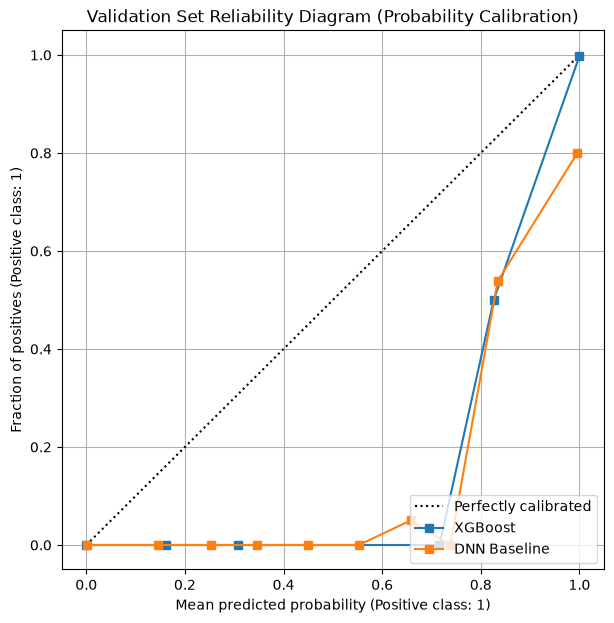

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))

CalibrationDisplay.from_predictions(y_val, xgb_val_probs, n_bins=10, name="XGBoost", ax=ax)
CalibrationDisplay.from_predictions(y_val, dnn_val_probs, n_bins=10, name="DNN Baseline", ax=ax)

ax.set_title("Validation Set Reliability Diagram (Probability Calibration)")
plt.grid(True)
plt.show()

In [14]:
# Step A: Extract test predictions using frozen configurations
xgb_test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
dnn_test_probs = get_dnn_probabilities(X_test_scaled)

xgb_test_preds = (xgb_test_probs >= best_xgb_threshold).astype(int)
dnn_test_preds = (dnn_test_probs >= best_dnn_threshold).astype(int)

# Step B: Print formal validation summaries for your thesis report
print("=================== FINAL FROZEN XGBOOST REPORT ===================")
print(f"Applied Decision Threshold: {best_xgb_threshold:.2f}")
print(confusion_matrix(y_test, xgb_test_preds))
print(classification_report(y_test, xgb_test_preds, digits=4))

print("\n==================== FINAL FROZEN DNN BASELINE REPORT ====================")
print(f"Applied Decision Threshold: {best_dnn_threshold:.2f}")
print(confusion_matrix(y_test, dnn_test_preds))
print(classification_report(y_test, dnn_test_preds, digits=4))

=================== FINAL FROZEN XGBOOST REPORT ===================
Applied Decision Threshold: 0.95
[[25207     1]
 [    4   323]]
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     25208
           1     0.9969    0.9878    0.9923       327

    accuracy                         0.9998     25535
   macro avg     0.9984    0.9939    0.9961     25535
weighted avg     0.9998    0.9998    0.9998     25535


==================== FINAL FROZEN DNN BASELINE REPORT ====================
Applied Decision Threshold: 0.80
[[25126    82]
 [   19   308]]
              precision    recall  f1-score   support

           0     0.9992    0.9967    0.9980     25208
           1     0.7897    0.9419    0.8591       327

    accuracy                         0.9960     25535
   macro avg     0.8945    0.9693    0.9286     25535
weighted avg     0.9966    0.9960    0.9962     25535



In [15]:
# Standardized probability wrappers for the explainers
def xgb_predict_proba_wrapper(x_numpy):
    # Map numpy matrix rows directly back to pandas format to preserve column naming indices natively
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    return xgb_model.predict_proba(df_temp)

def dnn_predict_proba_wrapper(x_numpy):
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    probs_class_1 = get_dnn_probabilities(df_temp)
    probs_class_0 = 1.0 - probs_class_1
    return np.column_stack((probs_class_0, probs_class_1))

# Step 3: baseline explanation setup

In [16]:
#Standardized LIME Explainers (Primary & Sensitivity)
feature_list = X_train_scaled.columns.tolist()
x_train_unresampled_numpy = X_train_scaled.values

# Primary Explainer: Continuous perturbations with KW=2.5 (balanced compromise)
lime_explainer_primary = lime.lime_tabular.LimeTabularExplainer(
    training_data=x_train_unresampled_numpy,
    feature_names=feature_list,
    class_names=["Benign", "Web Attack"],
    mode="classification",
    discretize_continuous=False,
    kernel_width=2.5,
    random_state=42
)

# Sensitivity Explainer: Discrete quartiles with KW=1.5 (attack-focused peak fidelity)
lime_explainer_sensitivity = lime.lime_tabular.LimeTabularExplainer(
    training_data=x_train_unresampled_numpy,
    feature_names=feature_list,
    class_names=["Benign", "Web Attack"],
    mode="classification",
    discretize_continuous=True,
    kernel_width=1.5,
    random_state=42
)

# Default alias pointing to primary configuration
lime_explainer = lime_explainer_primary
print("[*] LIME explainers initialized: Primary (Continuous, KW=2.5) & Sensitivity (Discrete, KW=1.5).")

[*] LIME explainers initialized: Primary (Continuous, KW=2.5) & Sensitivity (Discrete, KW=1.5).


In [17]:


# 1. Background dataset baseline for KernelExplainer
shap_background_baseline = shap.sample(X_train_scaled, 100, random_state=42)

# 2. KernelExplainers (Model-Agnostic Baseline in Probability Space)
shap_explainer_xgb_kernel = shap.KernelExplainer(
    model=xgb_predict_proba_wrapper,
    data=shap_background_baseline
)

shap_explainer_dnn = shap.KernelExplainer(
    model=dnn_predict_proba_wrapper,
    data=shap_background_baseline
)

# 3. TreeExplainer for XGBoost (Exact, Fast, Native Tree-Path)
shap_explainer_xgb_tree = shap.TreeExplainer(model=xgb_model)

In [18]:
#Rigorous Attribution Consensus Metrics & Extractor
def compute_attribution_metrics(attr_vec1, attr_vec2, k=None, k_values=None):
    """
    Computes stability and similarity metrics between two attribution vectors.
    Supports single k (e.g., k=10) or multiple thresholds (e.g., k_values=[3, 5, 10]).
    """
    if k is not None:
        target_ks = [k] if isinstance(k, int) else list(k)
    elif k_values is not None:
        target_ks = [k_values] if isinstance(k_values, int) else list(k_values)
    else:
        target_ks = [3, 5, 10]

    metrics = {}
    
    for k_val in target_ks:
        top_k_idx1 = set(np.argsort(np.abs(attr_vec1))[-k_val:])
        top_k_idx2 = set(np.argsort(np.abs(attr_vec2))[-k_val:])
        
        intersection = top_k_idx1.intersection(top_k_idx2)
        union = top_k_idx1.union(top_k_idx2)
        
        overlap_count = len(intersection)
        jaccard_sim = overlap_count / len(union) if len(union) > 0 else 0.0
        
        metrics[f'top_{k_val}_overlap'] = overlap_count
        metrics[f'jaccard_{k_val}'] = jaccard_sim
        
        # Localized Rank Correlation over the Union of Top-K features
        union_indices = list(union)
        slice1 = attr_vec1[union_indices]
        slice2 = attr_vec2[union_indices]
        
        if np.std(slice1) == 0 or np.std(slice2) == 0 or len(union_indices) < 2:
            rho = 0.0
        else:
            rho, _ = stats.spearmanr(slice1, slice2)
            rho = 0.0 if np.isnan(rho) else rho
            
        metrics[f'union_spearman_{k_val}'] = rho

        # Legacy aliases if called with a single k (for sensitivity audit cells)
        if len(target_ks) == 1:
            metrics['top_k_overlap'] = overlap_count / float(k_val)
            metrics['jaccard_similarity'] = jaccard_sim
            metrics['spearman_rank_corr'] = rho

    # Standard L2 attribution distance on unit vectors
    norm1 = np.linalg.norm(attr_vec1)
    norm2 = np.linalg.norm(attr_vec2)
    u1 = attr_vec1 / norm1 if norm1 > 0 else attr_vec1
    u2 = attr_vec2 / norm2 if norm2 > 0 else attr_vec2
    metrics['attribution_distance'] = np.linalg.norm(u1 - u2)
    
    return metrics


def extract_aligned_lime_attributions(instance, predict_fn, num_features, explainer=None):
    """
    Generates LIME attributions aligned to Class 1 using raw integer indices.
    Accepts an explainer instance dynamically to support both primary and sensitivity models.
    """
    active_explainer = lime_explainer if explainer is None else explainer

    if isinstance(instance, pd.DataFrame):
        data_row = instance.iloc[0].values
    elif isinstance(instance, pd.Series):
        data_row = instance.values
    else:
        data_row = instance

    exp = active_explainer.explain_instance(
        data_row=data_row,
        predict_fn=predict_fn,
        labels=(1,),
        num_features=num_features
    )
    
    raw_local_exp = exp.local_exp[1]
    index_to_weight = {feature_idx: weight for feature_idx, weight in raw_local_exp}
    
    total_features = x_train_unresampled_numpy.shape[1]
    lime_vector = np.zeros(total_features)
    for idx in range(total_features):
        lime_vector[idx] = index_to_weight.get(idx, 0.0)
        
    fidelity_score = exp.score
    return lime_vector, fidelity_score


def extract_aligned_shap_attributions(instance, explainer, nsamples=None):
    """
    Extracts Class 1 SHAP values supporting both KernelExplainer and TreeExplainer.
    Automatically handles 1D/2D shape conversions.
    """
    if isinstance(instance, np.ndarray):
        if instance.ndim == 1:
            instance_input = pd.DataFrame([instance], columns=X_train_scaled.columns)
        else:
            instance_input = pd.DataFrame(instance, columns=X_train_scaled.columns)
    elif isinstance(instance, pd.Series):
        instance_input = pd.DataFrame([instance.values], columns=X_train_scaled.columns)
    else:
        instance_input = instance

    if isinstance(explainer, shap.TreeExplainer):
        raw_values = explainer.shap_values(instance_input)
        if isinstance(raw_values, list):
            shap_vector = raw_values[1]
        elif isinstance(raw_values, np.ndarray):
            if raw_values.ndim == 3:
                shap_vector = raw_values[:, :, 1]
            elif raw_values.ndim == 2:
                shap_vector = raw_values[0]
            else:
                shap_vector = raw_values
        else:
            shap_vector = raw_values
        return np.array(shap_vector).flatten()

    nsamples_param = nsamples if nsamples is not None else 100
    raw_values = explainer.shap_values(instance_input, nsamples=nsamples_param, silent=True)
    
    if isinstance(raw_values, list):
        shap_vector = raw_values[1]
    elif isinstance(raw_values, np.ndarray):
        if raw_values.ndim == 3:
            shap_vector = raw_values[:, :, 1]
        elif raw_values.ndim == 2 and raw_values.shape[0] == 1:
            shap_vector = raw_values[0]
        elif raw_values.ndim == 2 and raw_values.shape[1] == 2:
            shap_vector = raw_values[:, 1]
        else:
            shap_vector = raw_values
    else:
        shap_vector = raw_values
        
    return np.array(shap_vector).flatten()

In [19]:
#Verification & Shape Alignment Check Across Explainers

sample_idx = 0
verification_sample = X_val_scaled.iloc[sample_idx].values

print("=================== SHAPE & ALIGNMENT CHECK ===================")

# 1. XGBoost Pipelines
lime_xgb_w, xgb_fid = extract_aligned_lime_attributions(
    instance=verification_sample,
    predict_fn=xgb_predict_proba_wrapper,
    num_features=X_val_scaled.shape[1]
)
shap_xgb_kernel_w = extract_aligned_shap_attributions(
    instance=verification_sample,
    explainer=shap_explainer_xgb_kernel,
    nsamples=100
)
shap_xgb_tree_w = extract_aligned_shap_attributions(
    instance=verification_sample,
    explainer=shap_explainer_xgb_tree
)

# 2. DNN Pipelines
lime_dnn_w, dnn_fid = extract_aligned_lime_attributions(
    instance=verification_sample,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=X_val_scaled.shape[1]
)
shap_dnn_w = extract_aligned_shap_attributions(
    instance=verification_sample,
    explainer=shap_explainer_dnn,
    nsamples=100
)

# Display diagnostic dimensions
print(f"XGBoost Pipeline -> LIME Vector Shape:        {lime_xgb_w.shape} | Fidelity R2: {xgb_fid:.4f}")
print(f"XGBoost Pipeline -> KernelSHAP Vector Shape: {shap_xgb_kernel_w.shape}")
print(f"XGBoost Pipeline -> TreeSHAP Vector Shape:   {shap_xgb_tree_w.shape}")
print(f"DNN Pipeline     -> LIME Vector Shape:        {lime_dnn_w.shape} | Fidelity R2: {dnn_fid:.4f}")
print(f"DNN Pipeline     -> KernelSHAP Vector Shape: {shap_dnn_w.shape}")

# Assert exact feature count matching
assert lime_xgb_w.shape == shap_xgb_tree_w.shape == shap_dnn_w.shape == (78,), "Dimension mismatch!"
print("\n[+] Success: All explainers executed smoothly and return matching 78-feature vectors.")
print("===============================================================")

=================== SHAPE & ALIGNMENT CHECK ===================
XGBoost Pipeline -> LIME Vector Shape:        (78,) | Fidelity R2: 0.0103
XGBoost Pipeline -> KernelSHAP Vector Shape: (78,)
XGBoost Pipeline -> TreeSHAP Vector Shape:   (78,)
DNN Pipeline     -> LIME Vector Shape:        (78,) | Fidelity R2: 0.0512
DNN Pipeline     -> KernelSHAP Vector Shape: (78,)

[+] Success: All explainers executed smoothly and return matching 78-feature vectors.


In [20]:


eval_samples = X_val_scaled.iloc[:15].values # Multi-observation evaluation sample
sampling_budgets = [100, 300, 500, 1000]
high_precision_budget = 2000

print("================= KERNELSHAP SAMPLING BUDGET SENSITIVITY =================")
budget_results = []

for idx, obs in enumerate(eval_samples):
    # Compute high-precision baseline attribution
    baseline_attr = extract_aligned_shap_attributions(
        obs, shap_explainer_dnn, nsamples=high_precision_budget
    )
    
    for budget in sampling_budgets:
        attr_budget = extract_aligned_shap_attributions(
            obs, shap_explainer_dnn, nsamples=budget
        )
        
        metrics = compute_attribution_metrics(baseline_attr, attr_budget, k=10)
        metrics['nsamples'] = budget
        metrics['obs_idx'] = idx
        budget_results.append(metrics)

# Aggregate and display summary
df_budget = pd.DataFrame(budget_results)
budget_summary = df_budget.groupby('nsamples').agg({
    'top_k_overlap': 'mean',
    'jaccard_similarity': 'mean',
    'spearman_rank_corr': 'mean',
    'attribution_distance': 'mean'
}).reset_index()

print("\n--- Stability Compared to Baseline (nsamples=2000) ---")
print(budget_summary.to_string(index=False))
print("==========================================================================")

================= KERNELSHAP SAMPLING BUDGET SENSITIVITY =================

--- Stability Compared to Baseline (nsamples=2000) ---
 nsamples  top_k_overlap  jaccard_similarity  spearman_rank_corr  attribution_distance
      100       0.353333            0.220938           -0.240291              0.964139
      300       0.546667            0.381319            0.175261              0.712507
      500       0.640000            0.497466            0.323549              0.621375
     1000       0.726667            0.581041            0.470382              0.509667


In [21]:
#Multi-Observation Background-Size Sensitivity Audit

background_sizes = [25, 50, 100, 200]
eval_subset = X_val_scaled.iloc[:15] # Evaluates multiple observations (e.g., 15 instances)
target_k = 10

# Pre-compute attributions using largest background size as baseline reference
baseline_bg = shap.sample(X_train_scaled, 200, random_state=42)
explainer_baseline = shap.KernelExplainer(dnn_predict_proba_wrapper, baseline_bg)

baseline_attributions = [
    extract_aligned_shap_attributions(eval_subset.iloc[i].values, explainer_baseline, nsamples=500)
    for i in range(len(eval_subset))
]

bg_audit_records = []

print("================ MULTI-OBSERVATION BACKGROUND SIZE AUDIT ================")

for size in background_sizes[:-1]: # Compare smaller sizes against the baseline (200)
    temp_background = shap.sample(X_train_scaled, size, random_state=42)
    temp_explainer = shap.KernelExplainer(dnn_predict_proba_wrapper, temp_background)
    
    size_metrics = []
    for i in range(len(eval_subset)):
        obs = eval_subset.iloc[i].values
        attr_temp = extract_aligned_shap_attributions(obs, temp_explainer, nsamples=500)
        
        # Calculate comparison metrics against baseline background size
        m = compute_attribution_metrics(baseline_attributions[i], attr_temp, k=target_k)
        size_metrics.append(m)
        
    df_size = pd.DataFrame(size_metrics)
    bg_audit_records.append({
        'Background Size': size,
        'Top-k Overlap (k=10)': df_size['top_k_overlap'].mean(),
        'Jaccard Similarity': df_size['jaccard_similarity'].mean(),
        'Rank Correlation (Spearman)': df_size['spearman_rank_corr'].mean(),
        'Attribution Distance (Norm L2)': df_size['attribution_distance'].mean()
    })

df_bg_summary = pd.DataFrame(bg_audit_records)
print(df_bg_summary.to_string(index=False))
print("=========================================================================")

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


================ MULTI-OBSERVATION BACKGROUND SIZE AUDIT ================
 Background Size  Top-k Overlap (k=10)  Jaccard Similarity  Rank Correlation (Spearman)  Attribution Distance (Norm L2)
              25              0.526667            0.376114                     0.112244                        0.733035
              50              0.540000            0.380385                     0.225252                        0.713693
             100              0.520000            0.373432                     0.134759                        0.747723


# Step 4 Agreement Analysis

In [22]:
# =====================================================================
# STEP 4.1: SEPARATE DETERMINISTIC COHORT SAMPLING FOR EACH MODEL
# =====================================================================

rng = np.random.default_rng(42)
target_sample_size = 50

def extract_model_cohorts(y_true, preds, probs, threshold):
    """
    Extracts True Positive, True Negative, False Positive, False Negative, 
    and Borderline sample indices specific to a given model's predictions and threshold.
    """
    tp_all_idx = np.where((y_true == 1) & (preds == 1))[0]
    tn_all_idx = np.where((y_true == 0) & (preds == 0))[0]
    fp_all_idx = np.where((y_true == 0) & (preds == 1))[0]
    fn_all_idx = np.where((y_true == 1) & (preds == 0))[0]

    # Sample strictly up to target size per standard quadrant
    sampled_tp = rng.choice(tp_all_idx, min(target_sample_size, len(tp_all_idx)), replace=False) if len(tp_all_idx) > 0 else np.array([])
    sampled_tn = rng.choice(tn_all_idx, min(target_sample_size, len(tn_all_idx)), replace=False) if len(tn_all_idx) > 0 else np.array([])
    sampled_fp = rng.choice(fp_all_idx, min(target_sample_size, len(fp_all_idx)), replace=False) if len(fp_all_idx) > 0 else np.array([])
    sampled_fn = rng.choice(fn_all_idx, min(target_sample_size, len(fn_all_idx)), replace=False) if len(fn_all_idx) > 0 else np.array([])

    # Master set of standard sampled indices to avoid reuse in borderline category
    standard_sampled_indices = set(np.concatenate([sampled_tp, sampled_tn, sampled_fp, sampled_fn]))

    # Calculate distance to THIS model's frozen threshold
    distances_to_threshold = np.abs(probs - threshold)
    sorted_by_closeness = np.argsort(distances_to_threshold)

    # Filter out rows already selected in standard categories
    borderline_idx = [idx for idx in sorted_by_closeness if idx not in standard_sampled_indices]
    sampled_borderline = np.array(borderline_idx[:target_sample_size])

    return {
        'True Positive': sampled_tp,
        'True Negative': sampled_tn,
        'False Positive': sampled_fp,
        'False Negative': sampled_fn,
        'Borderline Case': sampled_borderline
    }

# Build separate cohort index maps for both models independently
model_cohort_samples = {
    'XGBoost': extract_model_cohorts(y_test, xgb_test_preds, xgb_test_probs, best_xgb_threshold),
    'DNN': extract_model_cohorts(y_test, dnn_test_preds, dnn_test_probs, best_dnn_threshold)
}

print("=====================================================================")
print("         MODEL-SPECIFIC STRATIFIED STUDY COHORTS DISCOVERED          ")
print("=====================================================================")
for model_name, cohorts in model_cohort_samples.items():
    print(f"\n--- {model_name} Cohorts ---")
    for cohort, indices in cohorts.items():
        print(f" -> {cohort:18s} | Selected Samples: {len(indices)}")
print("=====================================================================")

         MODEL-SPECIFIC STRATIFIED STUDY COHORTS DISCOVERED          

--- XGBoost Cohorts ---
 -> True Positive      | Selected Samples: 50
 -> True Negative      | Selected Samples: 50
 -> False Positive     | Selected Samples: 1
 -> False Negative     | Selected Samples: 4
 -> Borderline Case    | Selected Samples: 50

--- DNN Cohorts ---
 -> True Positive      | Selected Samples: 50
 -> True Negative      | Selected Samples: 50
 -> False Positive     | Selected Samples: 50
 -> False Negative     | Selected Samples: 19
 -> Borderline Case    | Selected Samples: 50


In [23]:
#STEP 4.2 Agreement Loop with Primary & Sensitivity Configurations
agreement_records = []
num_features_total = X_test_scaled.shape[1]

# Pre-compute Monte Carlo random reference baselines for k = 3, 5, 10
print("[*] Running 10,000-iteration Monte Carlo random reference simulation...")
mc_k_values = [3, 5, 10]
mc_overlaps = {k: [] for k in mc_k_values}
all_feature_pool = np.arange(num_features_total)

for _ in range(10000):
    for k_val in mc_k_values:
        rand_set_a = set(rng.choice(all_feature_pool, k_val, replace=False))
        rand_set_b = set(rng.choice(all_feature_pool, k_val, replace=False))
        mc_overlaps[k_val].append(len(rand_set_a.intersection(rand_set_b)))

expected_random_overlap = {k: np.mean(mc_overlaps[k]) for k in mc_k_values}
expected_random_jaccard = {k: expected_random_overlap[k] / (2 * k - expected_random_overlap[k]) for k in mc_k_values}

for k in mc_k_values:
    print(f"     -> Random Top-{k:<2}: Overlap = {expected_random_overlap[k]:.2f}, Jaccard = {expected_random_jaccard[k]:.3f}")

print("\nEvaluating Multi-Model Consensus (Primary & Sensitivity Configurations)...")

lime_configs = [
    ('Primary (Cont KW=2.5)', lime_explainer_primary),
    ('Sensitivity (Disc KW=1.5)', lime_explainer_sensitivity)
]

for model_label, cohorts in model_cohort_samples.items():
    if model_label == 'XGBoost':
        predict_fn = xgb_predict_proba_wrapper
        explainer = shap_explainer_xgb_kernel
    else:
        predict_fn = dnn_predict_proba_wrapper
        explainer = shap_explainer_dnn

    for config_name, active_lime_exp in lime_configs:
        print(f"[*] Processing {model_label} under {config_name}...")
        for cohort_name, indices in cohorts.items():
            for test_idx in indices:
                instance_vector = X_test_scaled.iloc[test_idx].values
                
                lime_v, lime_r2 = extract_aligned_lime_attributions(
                    instance_vector, predict_fn, num_features_total, explainer=active_lime_exp
                )
                shap_v = extract_aligned_shap_attributions(instance_vector, explainer)
                
                row_metrics = {
                    'Cohort': cohort_name,
                    'Model': model_label,
                    'LIME_Config': config_name,
                    'Test_Index': test_idx,
                    'LIME_R2': lime_r2
                }
                
                # Compute metrics for k in [3, 5, 10]
                attr_metrics = compute_attribution_metrics(lime_v, shap_v, k_values=[3, 5, 10])
                for k in [3, 5, 10]:
                    row_metrics[f'Overlap_{k}'] = attr_metrics[f'top_{k}_overlap']
                    row_metrics[f'Jaccard_{k}'] = attr_metrics[f'jaccard_{k}']
                    row_metrics[f'Union_Spearman_{k}'] = attr_metrics[f'union_spearman_{k}']
                    row_metrics[f'Random_Overlap_{k}'] = expected_random_overlap[k]
                    row_metrics[f'Random_Jaccard_{k}'] = expected_random_jaccard[k]
                    
                agreement_records.append(row_metrics)

df_agreement = pd.DataFrame(agreement_records)
print("[+] Processing complete. Multi-configuration master agreement records generated.")

[*] Running 10,000-iteration Monte Carlo random reference simulation...
     -> Random Top-3 : Overlap = 0.11, Jaccard = 0.018
     -> Random Top-5 : Overlap = 0.31, Jaccard = 0.032
     -> Random Top-10: Overlap = 1.29, Jaccard = 0.069

Evaluating Multi-Model Consensus (Primary & Sensitivity Configurations)...
[*] Processing XGBoost under Primary (Cont KW=2.5)...
[*] Processing XGBoost under Sensitivity (Disc KW=1.5)...
[*] Processing DNN under Primary (Cont KW=2.5)...
[*] Processing DNN under Sensitivity (Disc KW=1.5)...
[+] Processing complete. Multi-configuration master agreement records generated.


In [24]:
#STEP 4.3 Publication Report with 95% Bootstrap CIs
def compute_bootstrapped_ci(data_series, n_bootstrap=5000, alpha=0.05):
    """Generates mean and lower/upper 95% confidence intervals via resampling."""
    if len(data_series) == 0:
        return 0.0, 0.0, 0.0
    
    values = data_series.values
    boot_means = []
    
    for _ in range(n_bootstrap):
        boot_sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(boot_sample))
        
    mean_val = np.mean(values)
    lower_bound = np.percentile(boot_means, (alpha / 2) * 100)
    upper_bound = np.percentile(boot_means, (1 - alpha / 2) * 100)
    return mean_val, lower_bound, upper_bound

report_rows = []
metrics_to_bootstrap = [
    'LIME_R2', 
    'Overlap_3', 'Overlap_5', 'Overlap_10',
    'Jaccard_3', 'Jaccard_5', 'Jaccard_10',
    'Union_Spearman_5', 'Union_Spearman_10'
]

unique_groups = df_agreement.groupby(['Cohort', 'Model', 'LIME_Config'])

for (cohort_name, model_type, config_type), group_df in unique_groups:
    row_summary = {
        'Cohort': cohort_name, 
        'Model': model_type,
        'LIME_Config': config_type,
        'N': len(group_df)
    }
    
    for metric in metrics_to_bootstrap:
        mean_v, low_v, high_v = compute_bootstrapped_ci(group_df[metric], n_bootstrap=5000)
        row_summary[metric] = f"{mean_v:.3f} [{low_v:.3f}, {high_v:.3f}]"
        
    row_summary['Rand_Overlap_10'] = f"{group_df['Random_Overlap_10'].iloc[0]:.2f}"
    row_summary['Rand_Jaccard_10'] = f"{group_df['Random_Jaccard_10'].iloc[0]:.3f}"
    
    report_rows.append(row_summary)

df_master_report = pd.DataFrame(report_rows)

print("\n" + "="*160)
print("                           FINAL XAI CONSENSUS MASTER REPORT (PRIMARY vs SENSITIVITY CONFIGURATIONS)")
print("="*160)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(df_master_report)
print("="*160)


                           FINAL XAI CONSENSUS MASTER REPORT (PRIMARY vs SENSITIVITY CONFIGURATIONS)


,Cohort,Model,LIME_Config,N,LIME_R2,Overlap_3,Overlap_5,Overlap_10,Jaccard_3,Jaccard_5,Jaccard_10,Union_Spearman_5,Union_Spearman_10,Rand_Overlap_10,Rand_Jaccard_10
0,Borderline Case,DNN,Primary (Cont KW=2.5),50,"0.761 [0.752, 0.769]","0.900 [0.700, 1.080]","1.560 [1.320, 1.800]","3.400 [3.060, 3.760]","0.200 [0.152, 0.248]","0.197 [0.164, 0.228]","0.212 [0.186, 0.239]","0.011 [-0.087, 0.106]","0.250 [0.181, 0.316]",1.29,0.069
1,Borderline Case,DNN,Sensitivity (Disc KW=1.5),50,"0.968 [0.968, 0.969]","0.460 [0.320, 0.620]","0.660 [0.480, 0.840]","1.600 [1.340, 1.860]","0.094 [0.062, 0.126]","0.076 [0.055, 0.098]","0.090 [0.075, 0.105]","-0.571 [-0.647, -0.493]","-0.588 [-0.641, -0.535]",1.29,0.069
2,Borderline Case,XGBoost,Primary (Cont KW=2.5),50,"0.766 [0.723, 0.798]","0.640 [0.420, 0.860]","1.140 [0.860, 1.400]","2.260 [1.960, 2.560]","0.150 [0.098, 0.208]","0.143 [0.108, 0.180]","0.132 [0.112, 0.154]","-0.080 [-0.186, 0.026]","0.200 [0.098, 0.292]",1.29,0.069
3,Borderline Case,XGBoost,Sensitivity (Disc KW=1.5),50,"0.974 [0.972, 0.975]","0.620 [0.460, 0.800]","1.180 [1.000, 1.360]","2.480 [2.180, 2.780]","0.132 [0.094, 0.172]","0.140 [0.116, 0.165]","0.146 [0.126, 0.165]","-0.458 [-0.528, -0.381]","-0.439 [-0.486, -0.391]",1.29,0.069
4,False Negative,DNN,Primary (Cont KW=2.5),19,"0.687 [0.604, 0.752]","0.789 [0.474, 1.105]","1.368 [1.053, 1.632]","2.842 [2.368, 3.316]","0.174 [0.105, 0.247]","0.165 [0.124, 0.202]","0.170 [0.138, 0.201]","0.167 [0.045, 0.287]","0.361 [0.264, 0.459]",1.29,0.069
5,False Negative,DNN,Sensitivity (Disc KW=1.5),19,"0.959 [0.941, 0.969]","0.526 [0.316, 0.737]","0.842 [0.632, 1.053]","2.105 [1.579, 2.579]","0.105 [0.063, 0.147]","0.095 [0.070, 0.121]","0.122 [0.091, 0.154]","-0.514 [-0.622, -0.409]","-0.498 [-0.556, -0.439]",1.29,0.069
6,False Negative,XGBoost,Primary (Cont KW=2.5),4,"0.637 [0.257, 0.901]","0.500 [0.000, 1.000]","1.000 [0.250, 1.750]","2.500 [1.000, 4.000]","0.100 [0.000, 0.200]","0.118 [0.028, 0.215]","0.154 [0.053, 0.263]","-0.577 [-0.780, -0.373]","-0.247 [-0.439, -0.056]",1.29,0.069
7,False Negative,XGBoost,Sensitivity (Disc KW=1.5),4,"0.972 [0.956, 0.980]","0.500 [0.000, 1.000]","0.750 [0.000, 1.500]","2.750 [2.250, 3.000]","0.100 [0.000, 0.200]","0.090 [0.000, 0.188]","0.160 [0.127, 0.176]","-0.329 [-0.732, 0.075]","-0.182 [-0.489, 0.140]",1.29,0.069
8,False Positive,DNN,Primary (Cont KW=2.5),50,"0.836 [0.822, 0.848]","1.200 [1.020, 1.380]","1.900 [1.640, 2.160]","3.860 [3.540, 4.200]","0.274 [0.224, 0.324]","0.251 [0.212, 0.290]","0.246 [0.220, 0.273]","0.090 [-0.004, 0.182]","0.215 [0.130, 0.298]",1.29,0.069
9,False Positive,DNN,Sensitivity (Disc KW=1.5),50,"0.976 [0.975, 0.977]","0.200 [0.100, 0.320]","0.680 [0.520, 0.840]","1.920 [1.620, 2.240]","0.040 [0.020, 0.064]","0.078 [0.057, 0.098]","0.111 [0.092, 0.130]","-0.656 [-0.701, -0.606]","-0.588 [-0.624, -0.551]",1.29,0.069
